# P2.12 · Learning updates and the complete calculation

**Maths fundamentals for transformers · Tiny Transformer**

The model needs a repeatable rule that converts local sensitivity into parameter changes of a controlled size.

**You will be able to:** An optimizer updates learned numbers using gradients; repeated forward, loss, backward and update steps train the model.

This notebook runs independently in Jupyter or Google Colab on a CPU. Download it from the course, then use **Colab → File → Upload notebook**. Public publication target: https://github.com/gkiri/tiny_repo. All required numerical examples are included.

The model connection uses the same **9,417-parameter transformer** as Unit 1: 65 characters, 32 positions, 28 features, two heads, learned position embeddings, LayerNorm and GELU.

In [1]:
#@title Setup: CPU, local Jupyter or Google Colab { display-mode: "form" }
# This notebook is self-contained. No account, secret, repository clone or GPU is required.
import sys, math, json, base64, zlib, hashlib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize": (7, 3), "figure.dpi": 100, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18})
print("Ready on CPU · PyTorch", torch.__version__)
print("All example data is included in this notebook.")

Ready on CPU · PyTorch 2.10.0+cpu
All example data is included in this notebook.


## Predict first

How do gradients change the model?

Write down your prediction before running the calculation.

A weight is 1, its gradient is −0.5, and the learning rate is 0.1. Compute one gradient-descent update.

## Work the numbers

1. Gradient descent: w − learning rate × gradient

2. AdamW tracks mean gradient and mean squared gradient

3. Correct initial bias; normalize update; apply weight decay

4. Repeat: forward → loss → zero_grad → backward → step

$$w_{\mathrm{new}}=w-\eta\nabla_wL,\qquad w\leftarrow(1-\eta\lambda)w-\eta\frac{\hat m}{\sqrt{\hat v}+\epsilon}$$

These small numbers are **Illustrative**. Each symbol names a quantity already shown above.

In [2]:
#@title Explicit teaching functions (expand to inspect) { display-mode: "form" }
"""P2's explicit calculations. Each function is checked against an independent PyTorch operation.

Rows use the final axis for features. Linear weights use PyTorch's [out, in] convention.
These readable implementations teach the operations; the reference model remains unchanged.
"""
import math
import torch


def dot(x, y):
    if x.shape != y.shape or x.ndim != 1:
        raise ValueError("dot needs two vectors of the same length")
    return (x * y).sum()


def linear(x, weight, bias):
    return x @ weight.transpose(-2, -1) + bias


def embeddings(ids, token_table, position_table):
    positions = torch.arange(ids.shape[-1], device=ids.device)
    if ids.shape[-1] > position_table.shape[0]:
        raise ValueError("the position table is shorter than the input")
    return token_table[ids] + position_table[positions]


def layernorm(x, gamma, beta, eps=1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    variance = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
    return (x - mean) / torch.sqrt(variance + eps) * gamma + beta


def softmax(scores, temperature=1.0):
    if temperature <= 0 or not math.isfinite(temperature):
        raise ValueError("temperature must be finite and positive")
    if torch.isnan(scores).any() or torch.isposinf(scores).any() or torch.isneginf(scores).all(dim=-1).any():
        raise ValueError("each score row needs a finite entry, with no NaN or positive infinity")
    scaled = scores / temperature
    shifted = scaled - scaled.max(dim=-1, keepdim=True).values
    positive = torch.exp(shifted)
    return positive / positive.sum(dim=-1, keepdim=True)


def attention(q, k, v):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    allowed = torch.ones(scores.shape[-2:], dtype=torch.bool, device=q.device).tril()
    masked = scores.masked_fill(~allowed, float("-inf"))
    shares = softmax(masked)
    return shares @ v, shares, masked


def gelu(x):
    cdf = 0.5 * (1 + torch.erf(x / math.sqrt(2)))
    return x * cdf


def residual(x, update):
    if x.shape != update.shape:
        raise ValueError("a residual update must have the same shape as its input")
    return x + update


def cross_entropy(logits, targets):
    log_prob = logits - torch.logsumexp(logits, dim=-1, keepdim=True)
    correct = log_prob.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    return -correct.mean()


def tiny_loss(w):
    """One adjustable logit: target 0, logits [2*w, 1, 0]."""
    z = torch.stack((2 * w, torch.ones_like(w), torch.zeros_like(w)))
    return cross_entropy(z.unsqueeze(0), torch.tensor([0], device=w.device))


def finite_difference(f, x, step=1e-5):
    return (f(x + step) - f(x - step)) / (2 * step)


def adamw_step(parameter, gradient, first, second, step, lr=0.003,
               betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01):
    """One AdamW update, including moment bias correction and decoupled weight decay."""
    beta1, beta2 = betas
    first = beta1 * first + (1 - beta1) * gradient
    second = beta2 * second + (1 - beta2) * gradient.square()
    first_hat = first / (1 - beta1 ** step)
    second_hat = second / (1 - beta2 ** step)
    parameter = parameter * (1 - lr * weight_decay) - lr * first_hat / (second_hat.sqrt() + eps)
    return parameter, first, second

print("Explicit functions loaded; each is independently tested against PyTorch.")

Explicit functions loaded; each is independently tested against PyTorch.


## Implement and verify

Read each line, predict its output, then run it. The explicit calculation and the PyTorch operation should agree.

In [3]:
w = torch.tensor(1., dtype=torch.float64, requires_grad=True)
loss = tiny_loss(w)
loss.backward()
new_w = w.detach() - .1 * w.grad
print("before", w.item(), loss.item())
print("after SGD", new_w.item(), tiny_loss(new_w).item())
p = torch.tensor([1.], dtype=torch.float64, requires_grad=True)
opt = torch.optim.AdamW([p], lr=.003)
opt.zero_grad(set_to_none=True)
tiny_loss(p[0]).backward()
opt.step()
print("after AdamW", p.item())

before 1.0 0.4076059644443806
after SGD 1.0669518088450356 0.3647465935560432


after AdamW 1.0029699999551918


## See it and change one thing

The plot is generated by the code. Change one input and predict how the picture will change before running it again.

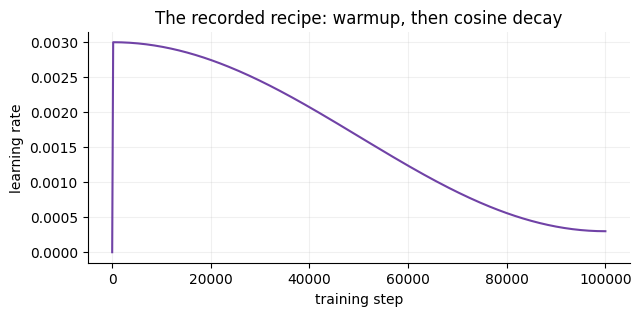

In [4]:
def lr_at(step):
    if step < 200: return .003 * step / 200
    p=min(1.,(step-200)/(100000-200))
    return .0003+.5*(.003-.0003)*(1+math.cos(math.pi*p))
steps=np.r_[np.linspace(0,200,40),np.linspace(200,100000,240)]
plt.plot(steps,[lr_at(s) for s in steps],color="#7042a6")
plt.xlabel("training step");plt.ylabel("learning rate");plt.title("The recorded recipe: warmup, then cosine decay");plt.show()

## Find it in the transformer

The following values were exported at full precision from the pinned Unit 1 checkpoint. Crops are for display; complete vectors are used in calculations.

Recorded input: `You taught me language; and my p`.

Reference lesson: **training-loop**.

In [5]:
#@title Recorded model fixture (included; no download) { display-mode: "form" }
recorded = json.loads('{"params":9417}')
print("Recorded: prompter-r1; input: You taught me language; and my p")

Recorded: prompter-r1; input: You taught me language; and my p


In [6]:
print("The complete model below has",recorded["params"],"learned scalars.")

The complete model below has 9417 learned scalars.


### AdamW: compare three explicit updates

The first moment averages gradients; the second averages squared gradients. Bias correction divides by `1 − βᵗ`. Epsilon stabilizes division. Weight decay is applied separately from the gradient. These are PyTorch’s defaults used by the recorded recipe, except its explicitly configured learning rate.

In [7]:
p=torch.tensor([1.,-2.],dtype=torch.float64,requires_grad=True)
opt=torch.optim.AdamW([p],lr=.003)
manual=p.detach().clone();m=torch.zeros_like(p);v=torch.zeros_like(p)
for step,g in enumerate([[.2,-.4],[-.3,.1],[0.,0.]],1):
    gradient=torch.tensor(g,dtype=p.dtype)
    manual,m,v=adamw_step(manual,gradient,m,v,step)
    opt.zero_grad(set_to_none=True);p.grad=gradient;opt.step()
    torch.testing.assert_close(manual,p,rtol=1e-12,atol=1e-12)
    print("step",step,"parameters",p.detach().tolist())

step 1 parameters [0.99697000015, -1.996940000075]
step 2 parameters [0.9976831964692539, -1.9954716874096927]
step 3 parameters [0.9982276886111275, -1.9943231225338]


## Complete model: forward, loss, backward, update

The next folded cell contains the actual reference model code and pinned checkpoint, included in this file. Training changes a disposable in-memory copy. The original checkpoint is never overwritten. This one-example step illustrates the mechanism; it is not an evaluation of generalization.

In [8]:
#@title The actual Unit 1 model (included source) { display-mode: "form" }
"""Our tiny transformer: 9,417 learned numbers that predict the next character of Shakespeare.

It reads up to 32 characters of text and gives a probability to each of the 65 characters that could come next. Writing is
that prediction in a loop: pick a character, append it, slide the 32-character window, and predict again. (The class is
called Prompter for the course's file names; learners meet it as "our tiny transformer".)

The architecture is the "10k" configuration of maxpolaczuk/tiny-character-transformer (a 1-block, 2-head character GPT on Tiny
Shakespeare). The code here is written fresh for the course (that repository has no licence, so none of its code or weights
are copied): every line is one the course teaches.

    characters ─► token table (65 × 28) + position table (32 × 28)        lookup:      what, and where
               ─► one block: LayerNorm ─► 2-head causal attention ─► +    look back:   which earlier letters matter
                             LayerNorm ─► feed-forward 28 → 56 → 28 ─► +  think:       transform each row on its own
               ─► final LayerNorm ─► readout with the token table again   score all 65 characters
               ─► softmax                                                  probabilities for the next character

Parameters: token table 1,820 · positions 896 · block 6,580 (two LayerNorms 112, q|k|v 2,436, attention out 812,
feed-forward 1,624 + 1,596) · final LayerNorm 56 · readout bias 65 = 9,417.
"""

import math
from dataclasses import asdict, dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F


@dataclass(frozen=True)
class Config:
    vocab_size: int = 65    # every distinct character in Tiny Shakespeare
    block_size: int = 32    # how many characters the model can read at once (its context)
    d_model: int = 28       # how many numbers describe one character in one place (a row)
    n_head: int = 2         # attention heads, each looking with 28 / 2 = 14 numbers
    d_ff: int = 56          # the feed-forward network's hidden width (2 × d_model)
    n_layer: int = 1        # transformer blocks

    def to_dict(self):
        return asdict(self)


class Tokenizer:
    """One id per character, in sorted order: '\\n' is 0, ' ' is 1, … 'z' is 64."""

    def __init__(self, text: str):
        self.chars = sorted(set(text))
        self.stoi = {c: i for i, c in enumerate(self.chars)}

    def encode(self, s: str) -> list[int]:
        return [self.stoi[c] for c in s]

    def decode(self, ids) -> str:
        return "".join(self.chars[int(i)] for i in ids)


class CausalSelfAttention(nn.Module):
    """Each row asks a question (q), every earlier row offers a label (k) and a message (v). A row reads the messages of the
    rows whose labels match its question best, never a row to its right."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.n_head, self.head_dim = cfg.n_head, cfg.d_model // cfg.n_head
        self.qkv = nn.Linear(cfg.d_model, 3 * cfg.d_model)     # q, k and v for both heads in one matrix
        self.proj = nn.Linear(cfg.d_model, cfg.d_model)        # mix the heads' results back into one row
        mask = torch.tril(torch.ones(cfg.block_size, cfg.block_size))
        self.register_buffer("mask", mask.view(1, 1, cfg.block_size, cfg.block_size), persistent=False)

    def forward(self, x, keep=None):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q, k, v = (t.view(B, T, self.n_head, self.head_dim).transpose(1, 2) for t in (q, k, v))
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)          # how well each question matches each label
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))   # no peeking at the future
        att = F.softmax(att, dim=-1)                                          # shares that add up to 1
        if keep is not None:
            keep["attn"] = att.detach()
        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)            # each row: a weighted mix of messages
        return self.proj(y)


class Block(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = CausalSelfAttention(cfg)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.ff = nn.Sequential(nn.Linear(cfg.d_model, cfg.d_ff), nn.GELU(), nn.Linear(cfg.d_ff, cfg.d_model))

    def forward(self, x, keep=None):
        x = x + self.attn(self.ln1(x), keep)    # look back, and add what was found to the row
        x = x + self.ff(self.ln2(x))            # think about each row on its own, and add that too
        return x


class Prompter(nn.Module):
    def __init__(self, cfg: Config = Config()):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)    # one learned row per character
        self.pos_emb = nn.Embedding(cfg.block_size, cfg.d_model)    # one learned row per place 0 … 31
        self.blocks = nn.Sequential(*[Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head_bias = nn.Parameter(torch.zeros(cfg.vocab_size))  # the readout reuses tok_emb (tied); only its bias is new
        self.apply(self._init)

    @staticmethod
    def _init(m):
        # small random numbers (σ = 0.02), so the untrained model's guesses are nearly even: its first loss is about
        # ln 65 = 4.17, the loss of a uniform guess over 65 characters
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
        if isinstance(m, nn.Linear) and m.bias is not None:
            nn.init.zeros_(m.bias)

    def forward(self, idx, targets=None, keep=None):
        T = idx.size(1)
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))   # what + where
        for b in self.blocks:
            x = b(x, keep)
        x = self.ln_f(x)
        logits = x @ self.tok_emb.weight.T + self.head_bias                         # a score for every character
        loss = None if targets is None else F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, n, temperature=1.0, generator=None):
        for _ in range(n):
            logits, _ = self(idx[:, -self.cfg.block_size:])
            probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
            nxt = torch.multinomial(probs, 1, generator=generator)
            idx = torch.cat([idx, nxt], dim=1)
        return idx


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

print("Reference model defined.")

Reference model defined.


In [9]:
#@title Load the included checkpoint { display-mode: "form" }
raw=zlib.decompress(base64.b64decode('...'))
assert hashlib.sha256(raw).hexdigest()=='f3de1512e36d7c5f4caae4a391afdf68dce94e0d016c3504dc1b2387a58073c7'
export=json.loads(raw)
net=Prompter(Config(**export['config']))
weights={t['name']:torch.tensor(np.frombuffer(base64.b64decode(t['data']),dtype='<f4').copy().reshape(t['shape'])) for t in export['weights']['tensors']}
net.load_state_dict(weights)
assert count_params(net)==9417
print("Loaded",count_params(net),"learned scalars from",export['run'])

Loaded 9417 learned scalars from prompter-r1


In [10]:
text="You taught me language; and my pr"
vocab=export['vocab']; ids=torch.tensor([[vocab.index(c) for c in text]])
x,targets=ids[:,:-1],ids[:,1:]
net.eval()
with torch.no_grad():
    logits,loss=net(x,targets)
    p=logits[0,-1].softmax(-1)
print("input",tuple(x.shape),"logits",tuple(logits.shape),"loss",loss.item())
print("most probable next character",repr(vocab[p.argmax().item()]))
net.train(); opt=torch.optim.AdamW(net.parameters(),lr=.003/200)
opt.zero_grad(set_to_none=True)
_,before=net(x,targets); before.backward()
print("parameters with a gradient",sum(p.numel() for p in net.parameters() if p.grad is not None))
opt.step()
with torch.no_grad(): _,after=net(x,targets)
print("one disposable training step:",before.item(),"→",after.item())
assert torch.isfinite(after)
print("One batch does not establish validation performance.")

input (1, 32) logits (1, 32, 65) loss 1.8233751058578491
most probable next character 'r'
parameters with a gradient 9417


one disposable training step: 1.8233751058578491 → 1.8175495862960815
One batch does not establish validation performance.


## A common trap

The illustrative SGD update explains direction. The real model trains with AdamW. One training step need not improve every example or validation loss.

### ✋ Your turn

A weight is 1, its gradient is −0.5, and the learning rate is 0.1. Compute one gradient-descent update.

In [11]:
answer = None  # TODO: make a prediction, then enter your answer

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert abs(float(answer) - 1.05) < 1e-6, 'Revisit the worked calculation above.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [12]:
#@title Show a solution { display-mode: "form" }
answer = 1.05

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert abs(float(answer) - 1.05) < 1e-6, 'Revisit the worked calculation above.'
    print("✓ right:", answer)

✓ right: 1.05


## Connect the dots

An optimizer updates learned numbers using gradients; repeated forward, loss, backward and update steps train the model.

Next: see these operations inside the whole machine in F0.

To explain this operation to someone else, name its inputs, calculate one output, give its PyTorch equivalent, and point to its place in the transformer.